In [2]:
import networkx as nx
from networkx.readwrite import json_graph
from gerrychain import Graph
import matplotlib.pyplot as plt
import requests
import json
import maup
import geopandas as gpd

In [11]:
alarm = gpd.read_file("./GA_ALARM/ga_alarm.shp")

<Axes: >

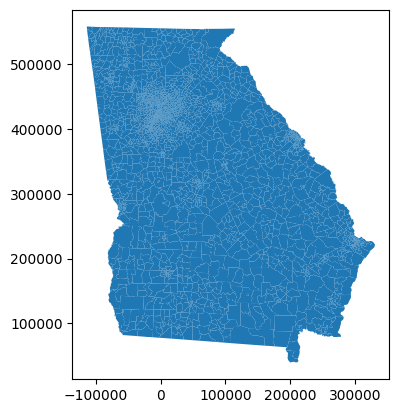

In [12]:
alarm.plot()

In [13]:
CON = gpd.read_file("./ga_cong_adopted_2023/Congress-2023 shape.shp")
SLDU = gpd.read_file("./ga_sldu_adopted_2023/Senate-2023 shape file.shp")
SLDL = gpd.read_file("./ga_sldl_adopted_2023/House-2023 shape.shp")

In [14]:
CON = CON.to_crs(alarm.crs)
SLDU = SLDU.to_crs(alarm.crs)
SLDL = SLDL.to_crs(alarm.crs)


p_to_CON = maup.assign(alarm,CON)
p_to_SLDU = maup.assign(alarm,SLDU.to_crs(alarm.crs))
p_to_SLDL = maup.assign(alarm,SLDL.to_crs(alarm.crs))

In [15]:
alarm["CON"] = p_to_CON
alarm["SLDU"] = p_to_SLDU
alarm["SLDL"] = p_to_SLDL

(-136222.765884975, 352986.12821807497, 13719.349532290005, 584053.7441009099)

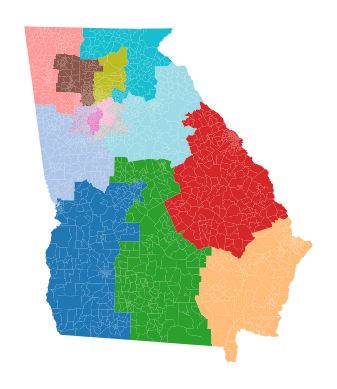

In [16]:
alarm.plot(column="CON",cmap='tab20')
plt.axis('off')

In [17]:
alarm['C_X'] = alarm.centroid.x
alarm['C_Y'] = alarm.centroid.y

In [ ]:
precinct_graph = Graph.from_geodataframe(alarm)


alarm.to_file("./output/GA_Processed_Precincts_ALARM.shp")

precinct_graph.to_json("./output/GA_Processed_Precincts_ALARM.json")

GeometryError: Invalid geometries at rows [1609, 2018] before reprojection. Consider repairing the affected geometries with `.buffer(0)`, or pass `ignore_errors=True` to attempt to create the graph anyways.

In [25]:
precinct_graph.nodes()[1609]

{'boundary_node': False,
 'area': 43892921.81394236,
 'GEOID': '131290849-B',
 'state': 'GA',
 'county': 'Gordon County',
 'muni': '12456',
 'cnty_mn': 'Gordon County12456',
 'cd_2010': 14,
 'cd_2020': 14,
 'vtd': '0849-B',
 'pop': 16943.0,
 'pop_hsp': 4393.0,
 'pop_wht': 10204.0,
 'pp_blck': 1154.0,
 'pop_ain': 26.0,
 'pop_asn': 453.0,
 'pop_nhp': 6.0,
 'pop_thr': 52.0,
 'pop_two': 655.0,
 'vap': 12636.0,
 'vap_hsp': 2776.0,
 'vap_wht': 8166.0,
 'vp_blck': 883.0,
 'vap_ain': 22.0,
 'vap_asn': 345.0,
 'vap_nhp': 6.0,
 'vap_thr': 38.0,
 'vap_two': 400.0,
 'pr_16_r_': 3461.7,
 'pr_16_d_': 1124.4,
 'uss_16_r_': 3325.7,
 'uss_16_d_': 911.4,
 'gv_18_r_': 3242.4,
 'gv_18_d_': 1126.1,
 'atg_18_r_': 3173.7,
 'atg_18_d_': 1149.8,
 'ss_18_r_': 3116.5,
 'ss_18_d_': 1135.3,
 'ss_r18_r_': 1036.6,
 'ss_r18_d_': 309.2,
 'pr_20_r_': 4476.5,
 'pr_20_d_': 1655.1,
 'uss_20_r_': 4404.6,
 'uss_20_d_': 1570.9,
 'arv_16': 3393.7,
 'adv_16': 1017.9,
 'arv_18': 3177.5,
 'adv_18': 1137.1,
 'arv_20': 4440.6,
 'a

In [26]:
[precinct_graph.nodes[x]["GEOID"] for x in precinct_graph.neighbors(1609)]

['13129000856', '13129000980', '131290849-A']